In [ ]:
import torch
import numpy as np


In [2]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
device

'mps'

In [3]:
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True

In [4]:
import datasets

poke_data = datasets.load_dataset("diffusers/pokemon-gpt4-captions")

/Users/markomirkovic/Documents/GitHub/DDL-Diffusion/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
print(poke_data)
print(poke_data["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 833
    })
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1280x1280 at 0x119114490>, 'text': 'A cheerful Bulbasaur ready for its next Pokémon adventure.'}


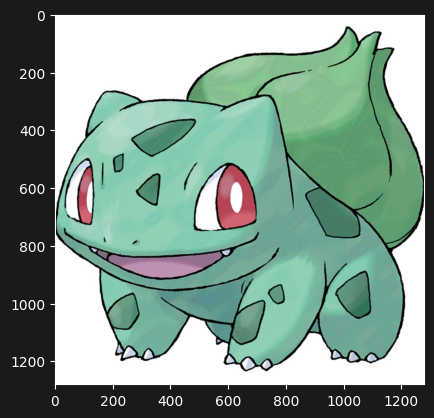

A cheerful Bulbasaur ready for its next Pokémon adventure.


In [6]:
import matplotlib.pyplot as plt

sample = poke_data["train"][0]
plt.imshow(sample["image"])
plt.show()
print(sample["text"])

In [ ]:
from torchvision import transforms as T

transforms = T.Compose([
    T.Resize(512),
    T.CenterCrop(512),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def preprocess(image):
    # Returns (3, 512, 512). Caller adds batch dim if needed.
    return transforms(image)

test_image = preprocess(sample["image"])
print(test_image.shape)
print(test_image.min(), test_image.max())


In [ ]:
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
vae.requires_grad_(False)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/Users/markomirkovic/Documents/GitHub/DDL-Diffusion/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [ ]:
x = preprocess(poke_data["train"][0]["image"]).unsqueeze(0).to(device)

with torch.no_grad():
    latent = vae.encode(x).latent_dist.sample() * 0.18215

print(latent.shape)
print(latent.min(), latent.max(), latent.mean(), latent.std())


In [ ]:
# Encode the WHOLE dataset -> latents.pt
from tqdm import tqdm

all_latents = []
batch_size = 4

for i in tqdm(range(0, len(poke_data["train"]), batch_size)):
    batch_items = poke_data["train"][i : i + batch_size]
    imgs = torch.stack([preprocess(im) for im in batch_items["image"]]).to(device)
    with torch.no_grad():
        latents = vae.encode(imgs).latent_dist.sample() * 0.18215
    all_latents.append(latents.cpu())  # .cpu() is critical — don't hoard on device

latents_tensor = torch.cat(all_latents, dim=0)
print(latents_tensor.shape)   # expect (~833, 4, 64, 64)
torch.save(latents_tensor, "latents.pt")


In [ ]:
# Cell F — Sanity check: decode a saved latent back to an image
# If this doesn't look like a Pokemon, your encoding has a bug.

latents = torch.load("latents.pt")
one = latents[0:1].to(device) / 0.18215      # undo the scaling
with torch.no_grad():
    decoded = vae.decode(one).sample          # (1, 3, 512, 512), values roughly in [-1, 1]
img = (decoded[0].cpu().clamp(-1, 1) + 1) / 2  # denormalize -> [0, 1]
img = img.permute(1, 2, 0).numpy()             # (H, W, C) for matplotlib
plt.imshow(img); plt.axis("off"); plt.show()

# Expect: a slightly fuzzy but recognizable Pokemon. VAE is lossy, so it
# won't be pixel-perfect — but it should be obviously the same creature.

In [ ]:
# Load CLIP tokenizer + text encoder.
# Same encoder Stable Diffusion uses: 768-dim vectors, fixed length 77.
from transformers import CLIPTokenizer, CLIPTextModel

CLIP_NAME = "openai/clip-vit-large-patch14"
tokenizer = CLIPTokenizer.from_pretrained(CLIP_NAME)
text_encoder = CLIPTextModel.from_pretrained(CLIP_NAME).to(device)
text_encoder.eval()
text_encoder.requires_grad_(False)


In [ ]:
# Smoke test: encode one caption and verify shape (1, 77, 768).
# Note: call the tokenizer object directly (not .tokenize) to get tensors back.
test_caption = poke_data["train"][0]["text"]

tokens = tokenizer(
    test_caption,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
)
input_ids = tokens.input_ids.to(device)

with torch.no_grad():
    test_emb = text_encoder(input_ids).last_hidden_state

print(test_emb.shape)   # expect (1, 77, 768)
print(test_emb.min(), test_emb.max(), test_emb.mean())


In [ ]:
# Encode ALL captions -> embeddings.pt
# Row i of embeddings.pt MUST line up with row i of latents.pt.
all_captions = [row["text"] for row in poke_data["train"]]
assert len(all_captions) == latents_tensor.shape[0], "caption count must match latent count"

all_input_ids = tokenizer(
    all_captions,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
).input_ids

all_embeddings = []
text_batch_size = 32
for i in tqdm(range(0, len(all_captions), text_batch_size)):
    batch_ids = all_input_ids[i : i + text_batch_size].to(device)
    with torch.no_grad():
        emb = text_encoder(batch_ids).last_hidden_state
    all_embeddings.append(emb.cpu())

embeddings_tensor = torch.cat(all_embeddings, dim=0)
print(embeddings_tensor.shape)   # expect (833, 77, 768)
torch.save(embeddings_tensor, "embeddings.pt")


In [ ]:
# Encode the EMPTY STRING -> uncond_embedding.pt
# Used for Classifier-Free Guidance (CFG) during training and inference.
uncond_ids = tokenizer(
    "",
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
).input_ids.to(device)

with torch.no_grad():
    uncond_embedding = text_encoder(uncond_ids).last_hidden_state

print(uncond_embedding.shape)   # expect (1, 77, 768)
torch.save(uncond_embedding.cpu(), "uncond_embedding.pt")


# Phase 3 — Diffusion Math

No neural network yet. We're just building the forward (noising) process and the constants it needs.

**The math, in one equation:**

$$x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

At `t=0`, `x_t == x_0` (clean image). At `t=T-1`, `x_t` is essentially pure Gaussian noise. The schedule controls how fast we get there.

**Why we pre-compute the schedule once:**
- Training will call `q_sample` thousands of times — recomputing `cumprod` each time is wasteful.
- Putting these on the model as **buffers** means they move with `.to(device)` automatically and get saved/loaded with the checkpoint.

**What you're building in the next 3 cells:**
1. A `NoiseScheduler` `nn.Module` that holds the constants.
2. A quick sanity check that the constants have the right shapes/values.
3. A visual test: noise a real Pokemon latent at `t=0`, `500`, `999`, decode, look at it.


In [ ]:
# Phase 3 — the NoiseScheduler class lives in scheduler.py.
# See that file for the full implementation + comments.
#
# autoreload makes Jupyter pick up edits to .py files without restarting the kernel.
%load_ext autoreload
%autoreload 2

from scheduler import NoiseScheduler


In [ ]:
# Cell L — Instantiate and sanity-check the schedule.
#
# The single most important check: alphas_cumprod[-1] should be tiny
# (well under 0.01). That means by t=T-1, almost no signal survives —
# x_T is essentially pure Gaussian noise, which is what we sample from
# at inference time.
#
# If alphas_cumprod[-1] is, say, 0.3, your "noise" still has 30% of the
# original signal in it. The model never learns to denoise pure noise,
# and inference produces washed-out replicas instead of new images.

scheduler = NoiseScheduler().to(device)

print("betas        :", scheduler.betas.shape, "on", scheduler.betas.device)
print("alphas_cumprod[0]    =", scheduler.alphas_cumprod[0].item(),  "(should be ~ 1.0)")
print("alphas_cumprod[-1]   =", scheduler.alphas_cumprod[-1].item(), "(should be ~ 0.0)")
print("beta[0]              =", scheduler.betas[0].item())
print("beta[-1]             =", scheduler.betas[-1].item())


In [ ]:
# Cell M — Visual test: noise one real Pokemon latent at three timesteps.
#
# Expected outcome when you eyeball the row of 3 images:
#   t=0    -> recognisable Pokemon (VAE-roundtripped, slightly fuzzy)
#   t=500  -> heavily corrupted, you can barely make out the silhouette
#   t=999  -> pure gray static, no structure at all
#
# If t=999 still looks like a Pokemon: schedule is too weak (or wrong).
# If t=0 looks noisy: you've added noise to the wrong term — check the
# order of arguments in q_sample.
#
# This is the LAST sanity gate before building the U-Net. After this,
# bugs in the forward process will silently corrupt every training step.

# Load latents from disk (we saved them in Phase 2). Take just one.
latents = torch.load("latents.pt")
x_0 = latents[0:1].to(device)               # (1, 4, 64, 64), already scaled by 0.18215

# Reuse the SAME noise across timesteps so the only thing changing is t.
# Makes the visual comparison cleaner.
noise = torch.randn_like(x_0)

timesteps_to_show = [0, 500, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(12, 4))

for ax, t_val in zip(axes, timesteps_to_show):
    # q_sample expects t as a (B,) long tensor on the correct device.
    t = torch.full((1,), t_val, device=device, dtype=torch.long)

    # Add noise according to the schedule.
    x_t = scheduler.q_sample(x_0, t, noise)

    # Decode back to pixel space so we can actually look at it.
    # Same recipe as Cell F: undo the 0.18215 scaling, run vae.decode,
    # denormalize from [-1, 1] back to [0, 1], move to CPU for matplotlib.
    with torch.no_grad():
        decoded = vae.decode(x_t / 0.18215).sample

    img = (decoded[0].cpu().clamp(-1, 1) + 1) / 2
    img = img.permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.set_title(f"t = {t_val}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# Phase 4 — U-Net

The U-Net is the **only** thing we're training. Its job:

$$\hat{\epsilon} = \text{UNet}(x_t, t, c) \approx \epsilon$$

Given a noisy latent `x_t`, the current timestep `t`, and the text embedding `c`, predict the noise that was added. Same shape in, same shape out: `(B, 4, 64, 64)`.

**The pieces, in build order:**

| # | Module | Job |
|---|---|---|
| N | `TimeEmbedding` | Turn integer `t` into a vector the network can use |
| O | `ResNetBlock` | The workhorse: conv → conv with time-conditioned residual |
| P | `SelfAttention` | Each spatial position looks at every other spatial position |
| Q | `CrossAttention` | Each spatial position attends to text tokens (this is how prompts steer the image) |
| R | `Downsample` / `Upsample` | Change spatial resolution |
| S | `UNet` | Wire it all together into the encoder/mid/decoder structure |
| T | Smoke test | Run a fake batch through, check output shape + param count |

**Why a U-Net specifically?**
Diffusion needs a model whose output is the same shape as its input. A U-Net does this naturally — encoder downsamples, decoder upsamples, skip connections preserve detail. The downsample/upsample pyramid is what lets a single network see both "where is the Pokemon" (low-res, global) and "what colour is this pixel" (high-res, local).

**Why attention?**
- **Self-attention** lets faraway pixels talk to each other (a Pokemon's left eye should look like its right eye).
- **Cross-attention** is *the* mechanism by which text controls the image. Without it, the text embedding goes nowhere.


In [ ]:
# Phase 4 — U-Net components live in unet.py.
# See that file for: TimeEmbedding, ResNetBlock, SelfAttention,
# CrossAttention, Downsample, Upsample, DownStage, UpStage, UNet.
from unet import UNet


In [ ]:
# Cell T — Smoke test the U-Net
#
# What we're checking:
#   1. Forward pass runs without a shape error anywhere.
#   2. Output shape matches input shape: (B, 4, 64, 64) in, (B, 4, 64, 64) out.
#   3. Parameter count is in the sane range (low millions).
#
# We use FAKE inputs (torch.randn) — we don't care about output quality yet,
# the model is freshly random. We just want to confirm wiring is correct.
#
# Common bugs this catches:
#   - Wrong skip-connection channel math (RuntimeError: shape mismatch in cat)
#   - Forgotten t_emb propagation (TypeError about missing argument)
#   - GroupNorm with num_channels not divisible by num_groups

model = UNet().to(device)

# Fake batch.
B = 2
x = torch.randn(B, 4, 64, 64, device=device)
t = torch.randint(0, 1000, (B,), device=device, dtype=torch.long)
c = torch.randn(B, 77, 768, device=device)

# Forward pass.
with torch.no_grad():
    out = model(x, t, c)

print("Output shape :", out.shape)        # expect torch.Size([2, 4, 64, 64])
print("Output dtype :", out.dtype)
print("Output mean  :", out.mean().item())
print("Output std   :", out.std().item())

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")
print(f"Approx size in float32: {n_params * 4 / 1e6:.1f} MB")


# Phase 5 — Training

We finally train the only thing that *is* trainable: the U-Net.

**Training objective** (just MSE):

$$L = \mathbb{E}_{x_0,\,\epsilon,\,t}\, \| \epsilon - \epsilon_\theta(x_t, t, c) \|^2$$

For each batch we:
1. Sample timesteps `t` uniformly across `[0, T)`.
2. Sample fresh noise `eps ~ N(0, I)`.
3. Build `x_t = sqrt(alpha_bar) * x_0 + sqrt(1 - alpha_bar) * eps` (via `q_sample`).
4. Apply **CFG dropout**: with p=0.1, swap the text embedding for the empty-string embedding.
5. Predict noise with the U-Net, MSE against the true noise.
6. Backprop, clip grads, step optimizer, step LR schedule.
7. Update the EMA shadow model.

**Three things that matter and are easy to skip:**
- **EMA**: at inference, use the EMA model, not the live one. The live model is jittery from each step's gradient; EMA averages it out.
- **CFG dropout**: without this, you can train the model fine but Classifier-Free Guidance at inference does nothing — the model never learned to handle empty conditioning.
- **Grad clip**: random init produces big gradients in the first few steps. One unclipped spike can NaN your whole run.

All of this lives in `train.py`. The notebook just wires it up and runs the loop.

**Heads up on MPS speed:** a forward+backward pass for our ~25M-param U-Net at batch 4 takes ~1-3s on M-series MPS. So 200 epochs × ~208 steps = ~12-24 hours. Either run overnight, or move to Colab T4 for ~10x speedup.


In [ ]:
# Cell U — Load precomputed data + build the DataLoader
# =============================================================================
#
# WHAT THIS CELL DOES
# -------------------
# 1. Loads the three tensor files we saved back in Phase 2.
# 2. Wraps the (latents, embeddings) pair in a Dataset so they stay aligned.
# 3. Wraps the Dataset in a DataLoader so we can iterate over shuffled batches.
#
# WHY WE'RE LOADING FILES INSTEAD OF RE-RUNNING THE VAE/CLIP
# -----------------------------------------------------------
# Phase 2 was a ONE-TIME computation. We paid the cost of running 833 images
# through the VAE and 833 captions through CLIP once and saved the results.
# At training time we just memory-map those files — no GPU spent on encoders,
# no need to even import diffusers/transformers.
#
# WHY KEEP TENSORS ON CPU UNTIL BATCH TIME
# -----------------------------------------
# - embeddings.pt is ~200MB. Hogging that much VRAM all the time is wasteful.
# - DataLoader can prefetch/move tensors efficiently per-batch.
# - On MPS the unified-memory model means CPU<->device transfer is basically free.
#
# WHAT A "DataLoader" ACTUALLY IS
# --------------------------------
# It's an iterator. Each time you ask it for a batch, it:
#   1. Picks the next BATCH_SIZE indices (shuffled at the start of each epoch).
#   2. Pulls those rows from the underlying Dataset.
#   3. Stacks them into a single tensor (or tuple of tensors).
#   4. Hands you the batch.
# A TensorDataset is the simplest Dataset: "rows 0..N-1 of these tensors,
# zipped together." Index i gives you (latents[i], embeddings[i]) — guaranteed
# to stay aligned because we built them in the same order back in Phase 2.

from torch.utils.data import TensorDataset, DataLoader

# Read tensors from disk. They went into these files via torch.save in Phase 2.
latents_tensor = torch.load("latents.pt")             # (833, 4, 64, 64) — VAE-encoded Pokemon
embeddings_tensor = torch.load("embeddings.pt")       # (833, 77, 768)   — CLIP-encoded captions
uncond_embedding = torch.load("uncond_embedding.pt")  # (1, 77, 768)     — CLIP-encoded ""

print("latents   :", latents_tensor.shape, latents_tensor.dtype)
print("embeddings:", embeddings_tensor.shape, embeddings_tensor.dtype)
print("uncond    :", uncond_embedding.shape, uncond_embedding.dtype)

# Push the uncond embedding to device once. It's tiny (1 × 77 × 768 ≈ 230KB)
# and used on EVERY training step (for CFG dropout), so it makes sense to
# move it once instead of every iteration.
uncond_embedding = uncond_embedding.to(device)

# Batch size: 4 is conservative for MPS / Colab T4. Bump to 8 or 16 if you
# have headroom. Bigger batch = faster training but more VRAM and noisier
# per-step gradients (which actually isn't bad for diffusion).
BATCH_SIZE = 4

# TensorDataset zips two tensors along dim 0. Index i returns
# (latents[i], embeddings[i]) — i.e., a Pokemon latent and its caption embedding.
train_dataset = TensorDataset(latents_tensor, embeddings_tensor)

# DataLoader settings worth understanding:
#   shuffle=True  : reshuffle the order every epoch. Without this the model
#                   would see batches in the same order forever, hurting
#                   generalization.
#   num_workers=0 : run data loading in the main process. With in-memory
#                   tensors there's nothing to "load" — extra workers would
#                   just add overhead. Use >0 only when reading from disk.
#   drop_last=True: if 833 isn't divisible by BATCH_SIZE, drop the leftover
#                   partial batch. Avoids the occasional batch with a different
#                   shape, which would slow down (or crash) JIT-style compilation.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True,
)

# Sanity print so you know how many optimizer steps fit in one epoch.
print(f"\nbatches per epoch: {len(train_loader)}")


In [ ]:
# Cell V — Instantiate everything for training
# =============================================================================
#
# WHAT THIS CELL DOES
# -------------------
# Builds the FIVE objects that the training loop needs and binds them together:
#
#   model          — the U-Net we're actually training
#   noise_scheduler— the q_sample / schedule constants (frozen, no grads)
#   ema_model      — a shadow of model, updated by smooth averaging
#   optimizer      — AdamW; holds the running mean+variance of each param's gradients
#   lr_scheduler   — adjusts optimizer's learning rate over time
#
# WHY THE ORDER MATTERS
# ---------------------
# Each object holds references to the previous one. If you build them out of
# order, you'll end up binding to stale state and silent bugs follow.
#
#   model -> ema_model:    deepcopy snapshot. Must happen AFTER model is moved
#                          to device; else ema lives on CPU and updates are slow.
#   model -> optimizer:    optimizer.parameters() must point at the model that
#                          will actually be updated. If you instantiate optimizer
#                          before model.to(device), the optimizer holds references
#                          to old CPU tensors and silently does nothing useful.
#   optimizer -> lr_scheduler: scheduler mutates optimizer.param_groups[0]["lr"]
#                              every step. It needs the same optimizer object.
#
# HYPERPARAMETERS — what to tweak first
# --------------------------------------
#   NUM_EPOCHS     : the most impactful knob. Drop to 5 for smoke testing,
#                    push to 200+ for a real run. Loss usually plateaus around
#                    100-200 epochs on this dataset.
#   LR             : 1e-4 is the safe default for diffusion. Higher = faster
#                    convergence but more NaN risk. Lower = slower but safer.
#   WEIGHT_DECAY   : 0.01 (AdamW default). Penalizes large weights — useful
#                    when overfitting an 833-sample dataset.
#   WARMUP_STEPS   : how long the LR ramps from 0 to LR before cosine decay.
#                    1000 is generous; you can drop to 500 for shorter runs.

from train import build_ema, make_optimizer, make_lr_schedule

# Top-level knobs. Change these here, NOT scattered across other cells.
NUM_EPOCHS = 200
TOTAL_STEPS = NUM_EPOCHS * len(train_loader)   # used by the LR schedule for cosine decay
WARMUP_STEPS = 1000
LR = 1e-4
WEIGHT_DECAY = 0.01

# 1. Fresh model. UNet() initialises with random weights — the rest of training
#    is moving those weights toward "predict noise correctly."
model = UNet().to(device)

# 2. Noise scheduler. Pure math, no learnable params, but it has buffers
#    (the schedule constants) that need to live on device for fast access.
noise_scheduler = NoiseScheduler().to(device)

# 3. EMA shadow. build_ema does:
#       ema = deepcopy(model); ema.requires_grad_(False); ema.eval()
#    Why deepcopy: ema must be a SEPARATE tensor in memory so its parameters
#    can drift slowly from the live model. A shallow reference would just
#    follow the live model exactly — defeating the point.
ema_model = build_ema(model)

# 4. Optimizer. AdamW = Adam + decoupled weight decay. The standard for
#    transformer-style models. Holds:
#       - running mean of each param's gradient (momentum)
#       - running mean of each param's squared gradient (variance)
#       - the parameter references themselves
optimizer = make_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)

# 5. LR schedule: linear warmup from 0 -> LR over WARMUP_STEPS, then cosine
#    decay back to 0 over the rest of TOTAL_STEPS. The schedule is "pluggable"
#    into the optimizer — calling lr_scheduler.step() each iteration mutates
#    optimizer.param_groups[0]["lr"] under the hood.
lr_scheduler = make_lr_schedule(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS,
)

print(f"Trainable params : {sum(p.numel() for p in model.parameters()):,}")
print(f"Total steps      : {TOTAL_STEPS:,}  ({NUM_EPOCHS} epochs × {len(train_loader)} batches)")
print(f"Warmup steps     : {WARMUP_STEPS}")
print(f"Peak LR          : {LR}")


In [ ]:
# Cell W — Smoke test: 5 training steps, expect loss to drop
# =============================================================================
#
# WHY THIS CELL EXISTS
# --------------------
# A full training run takes hours. A bug at step 1 (wrong shapes, wrong device,
# NaN gradients) wastes ALL of that time. This cell runs FIVE steps end-to-end
# and prints the loss after each. If the wiring is wrong it dies in <30 seconds.
#
# WHAT A "STEP" IS
# ----------------
# One training step =
#   forward pass through U-Net  +
#   compute MSE loss            +
#   backward pass (autograd)    +
#   gradient clip               +
#   optimizer.step()            +
#   lr_scheduler.step()         +
#   ema_update()
# Everything except the forward+backward is bookkeeping. The forward+backward
# is where 99% of the compute time goes.
#
# WHAT TO LOOK FOR IN THE OUTPUT
# ------------------------------
# step 0: loss ≈ 1.0       (random model predicting random noise → ~unit variance MSE)
# step 1: loss ≈ 0.9
# step 2: loss ≈ 0.8       (already learning — diffusion converges *fast* at the start)
# step 3: loss ≈ 0.7
# step 4: loss ≈ 0.6
#
# Numbers don't have to match exactly, but the trend must be down.
# - Flat losses → bug somewhere (probably no grads flowing).
# - Increasing losses → LR too high, or sign error in the loss.
# - NaN → grad clip not aggressive enough, or numerical issue (bf16, division).

from train import train_step

smoke_losses = []

# DataLoader is an iterable but not an iterator. `iter(...)` turns it into one
# so we can call next() repeatedly to pull batches without re-running shuffle.
data_iter = iter(train_loader)

for i in range(5):
    # Pull one batch: a tuple of (latents, embeddings).
    # Both are shape (BATCH_SIZE, ...). They live on CPU at this point.
    x_0, context = next(data_iter)

    # Move to the training device. On MPS this is essentially free; on CUDA
    # this is a host->device copy that happens in the background.
    x_0 = x_0.to(device)
    context = context.to(device)

    # train_step does all 7 sub-steps listed above. Returns the scalar loss.
    loss = train_step(
        model=model,
        ema_model=ema_model,
        noise_scheduler=noise_scheduler,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        x_0=x_0,
        context=context,
        uncond_embedding=uncond_embedding,
    )
    smoke_losses.append(loss)
    print(f"step {i}: loss = {loss:.4f}")

print("\nSmoke test passed if losses are finite (no NaN) and trending downward.")
print("If it passed, proceed to Cell X for the real training run.")


In [ ]:
# Cell X — Full training loop with checkpointing + resume
# =============================================================================
#
# THE STRUCTURE
# -------------
# Two nested loops:
#   OUTER LOOP  : epochs. One pass over the entire dataset = 1 epoch.
#   INNER LOOP  : batches within an epoch. Each iteration is one optimizer step.
#
# So total optimizer steps = NUM_EPOCHS × batches_per_epoch.
# For us that's e.g. 200 × 208 = 41600 steps.
#
# WHAT GETS TRACKED
# -----------------
# global_step    : monotonically increasing step counter (across all epochs).
#                  Used for LR schedule, for "log every N steps" cadence,
#                  and saved in checkpoints so resume is correct.
# loss_history   : every per-step loss, ever. Used by Cell Y to plot the curve.
# running_loss   : sum of losses since the last log line. Divided by running_count
#                  to display a smoothed average — single-step losses are very noisy.
#
# WHY tqdm
# --------
# tqdm wraps any iterable and prints a live progress bar with rate, ETA, and
# whatever metrics you stick on via set_postfix. Without it you'd stare at a
# silent terminal for 12 hours wondering if anything's happening.
#
# CHECKPOINTING
# -------------
# Every CHECKPOINT_EVERY epochs we dump model + ema_model + optimizer +
# lr_scheduler + step counters + loss_history to a .pt file. This file is
# everything you need to RESUME training byte-for-byte:
#   - model state: the weights we're training
#   - ema state: the smoothed weights for inference
#   - optimizer state: momentum + variance buffers (resetting these = restart Adam)
#   - lr_scheduler state: where in the schedule we are
#   - step/epoch: needed for the LR schedule to compute the right LR
#
# RESUMING
# --------
# Set RESUME_PATH = "checkpoints/epoch_50.pt" and rerun the cell. It loads
# state in place and starts from where you left off. RESUME_PATH = None
# always starts fresh (which is what you want the first time).

from tqdm.auto import tqdm
from train import train_step, save_checkpoint, load_checkpoint

# -- knobs --
CHECKPOINT_DIR = "checkpoints"   # directory to dump .pt files into
CHECKPOINT_EVERY = 25            # save every N epochs
LOG_EVERY = 50                   # update tqdm postfix every N steps
RESUME_PATH = None               # path to a checkpoint .pt, or None to start fresh

# State variables — initialised here, overwritten if resuming.
start_step = 0
start_epoch = 0
loss_history: list[float] = []

# Resume logic. If RESUME_PATH is set, we load all five state objects in place
# and pick up step/epoch from the checkpoint.
if RESUME_PATH is not None:
    start_step, start_epoch, loss_history = load_checkpoint(
        RESUME_PATH, model, ema_model, optimizer, lr_scheduler, map_location=device
    )
    # load_checkpoint loads to CPU then we re-move to device. Cheap on MPS.
    model.to(device)
    ema_model.to(device)
    print(f"Resumed from {RESUME_PATH}: step={start_step}, epoch={start_epoch}")

# Live tracking variables.
global_step = start_step
running_loss = 0.0   # accumulator since last log line
running_count = 0    # how many steps are in `running_loss`

# ---- OUTER LOOP: epochs ----
for epoch in range(start_epoch, NUM_EPOCHS):

    # Wrap the loader in tqdm for the live progress bar.
    # leave=False means the bar gets cleared when the epoch finishes,
    # so we don't accumulate 200 progress bars in the notebook output.
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{NUM_EPOCHS}", leave=False)

    # ---- INNER LOOP: batches ----
    for x_0, context in pbar:
        # Move to device (DataLoader gives us CPU tensors).
        x_0 = x_0.to(device)
        context = context.to(device)

        # One full training step. See Cell W for what's inside.
        loss = train_step(
            model=model,
            ema_model=ema_model,
            noise_scheduler=noise_scheduler,
            optimizer=optimizer,
            lr_scheduler=lr_scheduler,
            x_0=x_0,
            context=context,
            uncond_embedding=uncond_embedding,
        )

        # Track for plotting + display.
        loss_history.append(loss)
        running_loss += loss
        running_count += 1
        global_step += 1

        # Every LOG_EVERY steps, update the tqdm postfix with smoothed loss + current LR.
        # Single-step losses fluctuate wildly because of random t sampling; the
        # window-average is much more informative.
        if global_step % LOG_EVERY == 0:
            avg = running_loss / running_count
            pbar.set_postfix(
                loss=f"{avg:.4f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )
            running_loss = 0.0
            running_count = 0

    # End-of-epoch checkpoint. Also always save on the final epoch even if it's
    # not a multiple of CHECKPOINT_EVERY — you don't want to lose the last 24 epochs.
    if (epoch + 1) % CHECKPOINT_EVERY == 0 or epoch + 1 == NUM_EPOCHS:
        ckpt_path = f"{CHECKPOINT_DIR}/epoch_{epoch + 1}.pt"
        save_checkpoint(
            ckpt_path, model, ema_model, optimizer, lr_scheduler,
            step=global_step, epoch=epoch + 1, loss_history=loss_history,
        )
        print(f"saved checkpoint -> {ckpt_path}")

print("training complete.")


In [ ]:
# Cell Y — Plot the loss curve
# =============================================================================
#
# WHY THIS PLOT IS USEFUL
# -----------------------
# The training loop only ever shows a recent average in the tqdm bar.
# After training is done, the FULL loss curve tells you:
#   - Did training actually converge, or is loss still trending down?
#     (If still falling, you stopped too early — train longer.)
#   - Are there NaN / loss spikes anywhere? (Vertical jumps = unstable training.)
#   - Did the warmup work? (First 1000 steps should drop fast.)
#
# WHY THE NOISE
# -------------
# Diffusion loss varies HUGELY per step. Why? At each step we sample a random t.
# Some timesteps are easy (small t — near-clean input, model just denoises slightly).
# Others are very hard (large t — near-pure noise, model has to predict structure
# from nothing). The mix changes each batch, so per-step loss zigzags between 0.05
# and 0.5 even on a fully trained model. The MOVING AVERAGE removes this jitter
# and shows the real trend.
#
# WHY LOG SCALE ON Y-AXIS
# -----------------------
# Loss starts ~1.0 and ends ~0.05. On a linear scale, the late training is
# squished against the x-axis and you can't see whether it's still improving.
# Log scale spreads the small values out so the late-training curve is readable.

import numpy as np

losses = np.array(loss_history)

# Moving-average window = 1% of total steps. Smooths the curve without
# erasing real trends. Tweak window manually if you want more/less smoothing.
window = max(1, len(losses) // 100)
moving = np.convolve(losses, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))

# Raw per-step loss in light grey — for transparency, you can see the noise.
plt.plot(losses, alpha=0.25, label="per-step")

# Smoothed line on top. The convolution shortens the array by window-1, so
# we offset the x-axis accordingly.
plt.plot(np.arange(window - 1, len(losses)), moving, label=f"moving avg (w={window})")

plt.xlabel("step")
plt.ylabel("MSE loss")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()
